# Applications on SuiteSparse Matrices.

In this notebook, we assess the performance of TGDBEK on [SuiteSparse matrices](https://sparse.tamu.edu/). To access these matrices, we use the python interface `ssgetspy`, which is downloadable true `pip`. Moreover, we use the python package `scipy` and its submodules `sparse` and `mmread`. The latter is used to read the SuiteSparse matrices stored, after downloaded, on a file of extension `.mtx`.

## 1.  Installation, imports, and utilities

a1. Tensor toolbox

In [1]:
%%capture
!pip install -q git+https://github.com/jnlandu/tensor-tensor-toolbox-in-python

a2. randomized Kaczmarz algorithms

In [2]:
%%capture
!pip install -q git+https://github.com/jnlandu/tensor-randomized-kaczmarz-algorithms

a3. Install `ssgetpy`, the SuiteSparse matrix python interface.

In [3]:
%%capture
!pip install ssgetpy

b. imports and utilities

In [7]:
import os
import io, gzip, requests
import torch
import scipy as sp
import scipy.sparse as ssp
from scipy.io import mmread
import ssgetpy
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

from tensor_toolbox.config import device, DTYPE

from tensor_toolbox.tensorLinalg import (
    bcirc,
    t_product,
    t_transpose,
    t_frobenius_norm,
    t_pinv_apply,
    unfold,
    fold
)

from trk_algorithms.utils import (
    rel_se, make_partitions,
    make_tensor_problem,
    display_results,
    plot_convergence,
)
from trk_algorithms.methods import (
    trek_algorithm,
    trebk_algorithm,
    tregbk_algorithm,
    treabk_algorithm
)

In [21]:
# import torch

# import os
# import io, gzip, requests
# import numpy as np
# import scipy as sp
# import scipy.sparse as ssp
# from scipy.io import mmread

# import ssgetpy


### Utilities

In [8]:
#  Loads a list of matrixes.
def load_suitesparse(name=None, all = False, outdir="suitesparse_cache"):
    """
    name examples (SuiteSparse IDs):
      "HB/nos5"
      "Pajek/Cities"
      "Pajek/WorldCities"
      "HB/ash85"
      "GRE/gre_216a"   # depends on collection group

    The function download and load the corresponding sparse matrix
    """
    matrix_name_list = ['nos5', 'ash85', 'Cities', 'WorldCities', 'gre_216a']

    os.makedirs(outdir, exist_ok=True)

    if all == False:
        if name not in matrix_name_list:
            raise ValueError(f"name must be one of {matrix_name_list}")
        mat_obj = ssgetpy.fetch(name, location=outdir)
        root = os.path.join(outdir, name)
        path = os.path.join(root, f"{name}.mtx")
        A_sp = sp.io.mmread(path)

        if not sp.sparse.issparse(A_sp):
            A_sp = sp.coo_matrix(A_sp)

        return A_sp

    matrix_list =[]

    for name in matrix_name_list:
        mat_obj = ssgetpy.fetch(name, location=outdir)
        root = os.path.join(outdir, name)
        path = os.path.join(root, f"{name}.mtx")
        A_sp = sp.io.mmread(path)

        if not sp.sparse.issparse(A_sp):
            A_sp = sp.coo_matrix(A_sp)
            matrix_list.append(A_sp)

        matrix_list.append(A_sp)

    return matrix_list

#  Report on "density of the matrix"
def density_sparse(A_sp):
    m, n = A_sp.shape
    return A_sp.nnz / (m * n)

def report_sparse(A_sp, name="A"):
    m, n = A_sp.shape
    print(f"{name}: shape=({m},{n}), nnz={A_sp.nnz}, density={density_sparse(A_sp):.6f}")

In [9]:
ssp_mat_list= load_suitesparse(all=True)
# Test load  and density report of the sparse matrix:
A_csr = ssp_mat_list[0]
report_sparse(A_csr, "nos5")

nos5:   0%|          | 0/13125 [00:00<?, ?B/s]

ash85:   0%|          | 0/1037 [00:00<?, ?B/s]

Cities:   0%|          | 0/4989 [00:00<?, ?B/s]

WorldCities:   0%|          | 0/22374 [00:00<?, ?B/s]

gre_216a:   0%|          | 0/3096 [00:00<?, ?B/s]

nos5: shape=(468,468), nnz=5172, density=0.023614


#### Convert matrix to tensors

In [16]:
def matrix_to_tensor_split_cols(M_csr, p, device=None, dtype=torch.float32):
    m0, n0 = M_csr.shape
    assert n0 % p == 0, "Need n0 divisible by p (or use the split-rows version)."
    N1 = m0
    N2 = n0 // p

    # NOTE: dense conversion can be expensive; choose moderate matrices first.
    Md = M_csr.toarray().astype(np.float32)  # (m0, n0)

    A_np = Md.reshape((N1, N2, p), order="F")  # MATLAB-like reshape
    A = torch.from_numpy(A_np).to(device=device, dtype=dtype)
    return A  # (N1, N2, p)

def matrix_to_tensor_split_rows(M_csr, p, device=None, dtype=torch.float32):
    m0, n0 = M_csr.shape
    assert m0 % p == 0, "Need m0 divisible by p (or use the split-cols version)."
    # N1 = m0
    N1 = m0 // p
    N2 = n0

    # NOTE: dense conversion can be expensive; choose moderate matrices first.
    Md = M_csr.toarray().astype(np.float32)  # (m0, n0)

    A_np = Md.reshape((N1, N2, p), order="F")  # MATLAB-like reshape
    A = torch.from_numpy(A_np).to(device=device, dtype=dtype)
    return A  # (N1, N2, p)

#### Make tensor system

In [17]:
def make_tensor_system_from_A(A, K=10, noise_level=1e-3, seed=0, rcond=1e-3):
    """
    A: (N1, N2, p)
    X_star: (N2, K, p)  randn
    B = A*X_star + eps  with eps scaled like a relative noise
    """
    torch.manual_seed(seed)
    N1, N2, p = A.shape

    X_star = torch.randn(N2, K, p, device=A.device, dtype=A.dtype)

    B_clean = t_product(A, X_star)

    E = torch.randn_like(B_clean)
    E = E / (t_frobenius_norm(E) + 1e-12)
    eps = noise_level * t_frobenius_norm(B_clean) * E

    B = B_clean + eps
    X_ls = t_pinv_apply(A, B, rcond=rcond)
    return X_ls, X_star, B


## 2. Tensor greedy double block extended Kaczmarz (TGDBEK)

In [18]:
def tgdbek_algorithm(A, B, T, x_ls, alpha=1.0, eta=0.9, tol=1e-5, rcond=1e-3):
    """
    Tensor greedy double block extended Kaczmarz algorithm.
    It solves the tensor inconsistent system AX=B+eps, where A,
    X, B,and eps are tensors.

    Parameters
    ----------
    A : (m, n, p) tensor.
    B: (m, k, p) tensor.
    T: int. max iterations.
    x_ls: (n, k, p) tensor reference (e.g. least-squares solution).
    eta: greedy threshold. Default .9.
    tol: tolerance. Default 1e-5.
    rcond: relative condition number for torch.linalg.pinv. Default 1e-3.

    Returns:
    --------
    (X_np, iters, res_hist, x_hist_np), runtime
    where X_np is the solution, iters is the number of iterations required to
    exceed the tolerance or  to exceed T, res_hist is the relative error and
    finally runtime is the required running time.

    """
    m, n, p = A.shape
    m_b, k, p_b = B.shape

    # Check dimensional compatibility
    assert (m == m_b) and (p == p_b), "A:(m,n,p), B:(m,k,p) required"

    # Initailize the device and the data type
    device = A.device
    dtype = A.dtype

    #  Initialize
    X = torch.zeros((n, k, p), dtype=dtype, device=device)
    Z = B.clone()

    #  Precompute Frob norm squares of tensor columns  and row slices.
    col_norms_sq = torch.sum(A**2, dim=(0, 2)) + 1e-12               # ||A_{:,j,:}||_F^2 over dims (0,2); shape (n,)
    row_norms_sq = torch.sum(A**2, dim=(1, 2)) + 1e-12               # ||A_{i,:,:}||_F^2 over dims (1,2); shape (m,)

    res_hist = []
    x_hist = []

    res_hist.append(float(rel_se(X, x_ls).item()))
    x_hist.append(X.clone())

    #  Start the loop
    t0 = time.time()
    with torch.no_grad():
        for iter_k in range(T):

            # ========== The Z-step ========:
            trans_A = t_transpose(A)                                 # (n, m, p)
            trans_A_Z = t_product(trans_A, Z)                        # (n, m, p) * (m, k, p) = (n, k, p)
            scores_z = torch.sum(trans_A_Z**2, dim=(1, 2)) / col_norms_sq

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.

            del trans_A                                             # to free memory
            del trans_A_Z                                           # to free memory

            eps_z = eta * torch.max(scores_z)
            U_k = torch.where(scores_z >= eps_z)[0]

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.
            del eps_z
            del scores_z


            #  Block projection and update:
            A_U = A[:, U_k, :]                           # (m, |U|, p)
            W = t_pinv_apply(A_U, Z, rcond=rcond)        # (|U|, k, p) = (A_U)^dagger * Z
            Z = Z - alpha * t_product(A_U, W)            # (m, k, p)

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.
            del W, A_U, U_k

            # =========================================================
            # X-step: corrected greedy set J_k (row-wise residual!)
            # =========================================================
            AX = t_product(A, X)                        # (m, k, p)
            R = B - Z - AX                              # (m, k, p)

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.
            del AX

            scores_x = torch.sum(R**2, dim=(1, 2)) / row_norms_sq
            eps_x = eta * torch.max(scores_x)
            J_k = torch.where(scores_x >= eps_x)[0]

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.

            del R, scores_x, eps_x


            # Block projection and update
            A_J = A[J_k, :, :]                                             # (|J|, n, p)
            rhs = B[J_k, :, :] - Z[J_k, :, :] - t_product(A_J, X)          # (|J|, k, p)
            dX = t_pinv_apply(A_J, rhs, rcond=rcond)                       # (n, k, p)
            X = X + alpha *  dX

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.
            del A_J, rhs, dX

            #============ RSE and tolerance ======
            rse = rel_se(X, x_ls)
            res_hist.append(float(rse))
            x_hist.append(X.clone())

            if rse < tol:
                break

    runtime = time.time() - t0

    return (
        X.detach().cpu().numpy(),
        iter_k + 1,
        np.array(res_hist),
        np.array([x.detach().cpu().numpy() for x in x_hist])
    ), runtime


## 3. Run experiments

### 3.1. HB/nos5

#### Set the problem

In [19]:
## p doit etre un diviseur de n.
A_csr = ssp_mat_list[0]
p = 12
M_sp = matrix_to_tensor_split_cols(A_csr, p, device=None, dtype=torch.float32)
m, n, _ = M_sp.shape

print(f"Shape of M: {M_sp.shape}")

noise_level=1e-2

X_sp_ls, X_true,  B_sp = make_tensor_system_from_A(M_sp, K=p, noise_level=noise_level, seed=1)

print(f"Shape of X_true:{X_true.shape}, shape of X_ls: {X_sp_ls.shape}")

tol = 1e-6
alpha =12.0
delta = .7
eta=.5
max_iter = 300

Shape of M: torch.Size([468, 39, 12])
Shape of X_true:torch.Size([39, 12, 12]), shape of X_ls: torch.Size([39, 12, 12])


#### Partitions utilities

In [20]:
#  1. Partitions for TREBK. It requires both row and col partitions. # In the paper, they used
#  Sequential generations with s= number of partitions, and tau = their size.
row_partitions_trebk_sp = make_partitions(m,  tau=10, sequential=True)
col_partitions_trebk_sp = make_partitions(n, tau=10, sequential=True)

#  2. Partitions for TREGBK. It only requires partitioning the rows in s blocks
row_partitions_tregbk_sp = make_partitions(m, tau=10, sequential=True)

#  3. Partitions for TREABK:  The same block partitions style as 1.
row_partitions_treabk_sp = make_partitions(m, tau=10, sequential=True)
col_partitions_treabk_sp = make_partitions(n, tau=10, sequential=True)

print(f"Row and col  partitions TREBK: {(len(row_partitions_treabk_sp), len(col_partitions_trebk_sp))}")
print(f"Row and col  partitions TREGBK: {(len(row_partitions_tregbk_sp), "_ ")}")
print(f"Row and col  partitions TREABK: {(len(row_partitions_treabk_sp), len(col_partitions_treabk_sp))}")

Row and col  partitions TREBK: (47, 4)
Row and col  partitions TREGBK: (47, '_ ')
Row and col  partitions TREABK: (47, 4)


#### Run experiments for HB/nos5

In [21]:

(X_trek_sp, k_trek_sp, hist_trek_sp, x_hist_trek_sp), t_trek_sp = trek_algorithm(M_sp, B_sp,  x_ls=X_sp_ls, T=max_iter, tol=tol)


(X_trebk_sp, k_trebk_sp, hist_trebk_sp, x_hist_trebk_sp), t_trebk_sp = trebk_algorithm(M_sp, B_sp,x_ls =X_sp_ls,T=max_iter, tol=tol,\
                                              row_partitions=row_partitions_trebk_sp, col_partitions=col_partitions_trebk_sp)

(X_tregbk_sp, k_tregbk_sp, hist_tregbk_sp, x_hist_tregbk_sp), t_tregbk_sp  = tregbk_algorithm(M_sp, B_sp, x_ls =X_sp_ls,T=max_iter, delta=delta, tol=tol, \
                                              row_partitions=row_partitions_tregbk_sp)

# (X_treabk_sp, k_treabk_sp, hist_treabk_sp, x_hist_treabk_sp), t_treabk_sp = treabk_algorithm(M_sp, B_sp, x_ls =X_sp_ls,T=max_iter, alpha=alpha, tol=tol,\
#                                         row_partitions=row_partitions_treabk_sp, col_partitions=col_partitions_treabk_sp)

(X_tgdbek_f_sp, k_tgdbek_f_sp, hist_tgdbek_f_sp, x_hist_tgdbek_f_sp), t_tgdbek_f_sp = tgdbek_algorithm(M_sp, B_sp, T=max_iter, x_ls=X_sp_ls, alpha=1.0, eta=eta, tol=tol, rcond=1e-1)

# (X_tgdbek_rnd_sp, k_tgdbek_rnd_sp, hist_tgdbek_rnd_sp, x_hist_tgdbek_rnd_sp), t_tgdbek_sp = tgdbek_algorithm_faithful_rnd_row(M_sp, B_sp, T=max_iter, x_ls=X_sp_ls,eta=eta, tol=tol)




In [22]:
results = [
    {'name': 'TREK', 'time': t_trek_sp, 'final_residual': hist_trek_sp[-1], 'iterations': k_trek_sp},
    {'name': 'TREBK', 'time': t_trebk_sp, 'final_residual': hist_trebk_sp[-1], 'iterations': k_trebk_sp},
    {'name': 'TREGBK', 'time': t_tregbk_sp, 'final_residual': hist_tregbk_sp[-1], 'iterations': k_tregbk_sp},
    # {'name': 'TREABK', 'time': t_treabk_sp, 'final_residual': hist_treabk_sp[-1], 'iterations': k_treabk_sp},
    # {'name': 'TGDBEK (Proposed)', 'time': t_tgdbek_sp, 'final_residual': hist_tgdbek_sp[-1], 'iterations': k_tgdbek_sp},
    {'name': 'TGDBEK _f (good)', 'time': t_tgdbek_f_sp, 'final_residual': hist_tgdbek_f_sp[-1], 'iterations': k_tgdbek_f_sp},
    # {'name': 'TGDBEK _f (random)', 'time': t_tgdbek_sp, 'final_residual': hist_tgdbek_rnd_sp[-1], 'iterations': k_tgdbek_rnd_sp}
  ]

display_results(results)

BENCHMARK RESULTS - TENSOR KACZMARZ METHODS (Using T-Product)
          Method  Time (s)  Final Relative Residual  Iterations
            TREK  0.594666             1.046636e-01         300
           TREBK  1.122390             9.958111e-07         143
          TREGBK  1.131702             9.900874e-07         124
TGDBEK _f (good)  0.804104             9.641740e-07          44


,Method,Time (s),Final Relative Residual,Iterations
0,TREK,0.594666,1.046636e-01,300
1,TREBK,1.122390,9.958111e-07,143
2,TREGBK,1.131702,9.900874e-07,124
3,TGDBEK _f (good),0.804104,9.641740e-07,44


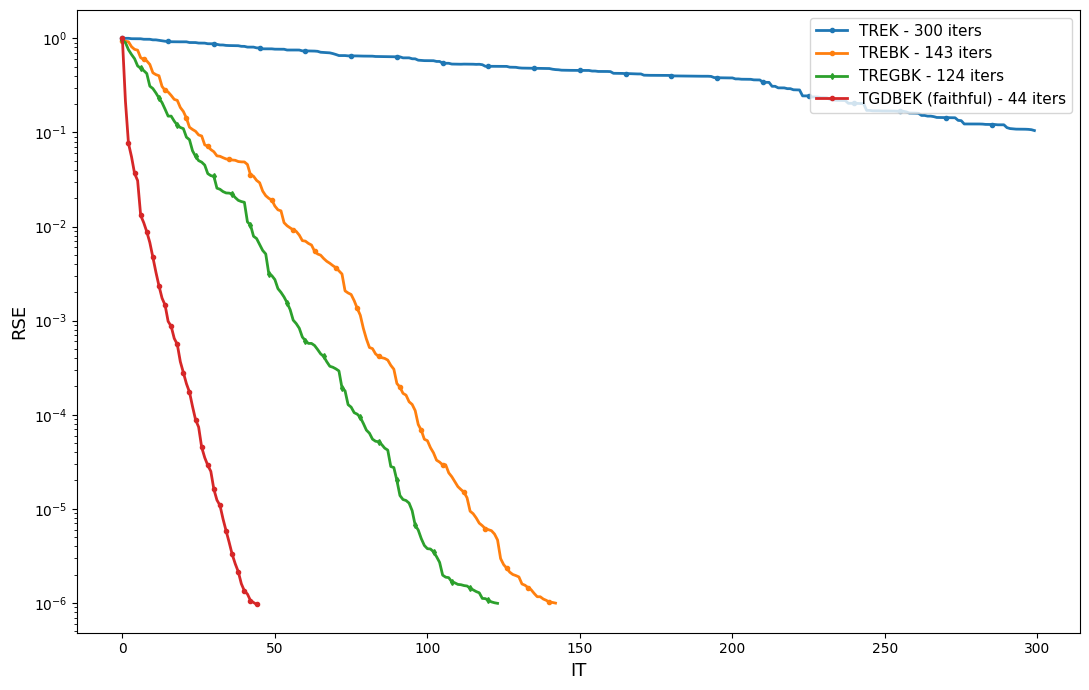

In [23]:
histories = [
  {'name': 'TREK', 'history': hist_trek_sp, 'iterations': k_trek_sp},
  {'name': 'TREBK', 'history': hist_trebk_sp, 'iterations': k_trebk_sp},
  {'name': 'TREGBK', 'history': hist_tregbk_sp, 'iterations': k_tregbk_sp, 'marker': 'd'},
  # {'name': 'TREABK', 'history': hist_treabk_sp, 'iterations': k_treabk_sp},
  {'name': 'TGDBEK (faithful)', 'history': hist_tgdbek_f_sp, 'iterations': k_tgdbek_f_sp},
  # {'name': 'TGDBEK (random)', 'history': hist_tgdbek_rnd_sp, 'iterations': k_tgdbek_rnd_sp,'linewidth': 2.5, 'linestyle': '--', 'marker': 'd'}
]
plot_convergence(histories)

### 3.2. ash85

#### Set the problem

In [25]:
# load the sparse matrix:
#  matrix_name_list = ['nos5', 'ash85', 'Cities', 'WorldCities', 'gre_216a']
A_csr = ssp_mat_list[1]
report_sparse(A_csr, "ash85")


# p = 5
# M_csr = matrix_to_tensor_split_cols(A_csr, p, device=None, dtype=torch.float32)
# print("tensor density:", tensor_density(M_csr))
# print("Shape of M", M_csr.shape)



# p doit etre un diviseur de n. p = 5
p = 5
M_sp = matrix_to_tensor_split_cols(A_csr, p, device=None, dtype=torch.float32)
m, n, _ = M_sp.shape

print(f"Shape of M: {M_sp.shape}")

noise_level=1e-3

X_sp_ls, X_true,  B_sp = make_tensor_system_from_A(M_sp, K=p, noise_level=noise_level, seed=1)

print(f"Shape of X_true:{X_true.shape}, shape of X_ls: {X_sp_ls.shape}")

tol = 1e-6
alpha =12.0
delta = .7
eta=.5

ash85: shape=(85,85), nnz=523, density=0.072388
Shape of M: torch.Size([85, 17, 5])
Shape of X_true:torch.Size([17, 5, 5]), shape of X_ls: torch.Size([17, 5, 5])


#### Partitions utilities

In [26]:

# Partitions
#  1. Partitions for TREBK. It requires both row and col partitions. # In the paper, they used
#  Sequential generations with s= number of partitions, and tau = their size.
row_partitions_trebk_sp = make_partitions(m,  tau=10, sequential=True)
col_partitions_trebk_sp = make_partitions(n, tau=10, sequential=True)

#  2. Partitions for TREGBK. It only requires partitioning the rows in s blocks
row_partitions_tregbk_sp = make_partitions(m, tau=10, sequential=True)

#  3. Partitions for TREABK:  The same block partitions style as 1.
row_partitions_treabk_sp = make_partitions(m, tau=10, sequential=True)
col_partitions_treabk_sp = make_partitions(n, tau=10, sequential=True)

print(f"Row and col  partitions TREBK: {(len(row_partitions_treabk_sp), len(col_partitions_trebk_sp))}")
print(f"Row and col  partitions TREGBK: {(len(row_partitions_tregbk_sp), "_ ")}")
print(f"Row and col  partitions TREABK: {(len(row_partitions_treabk_sp), len(col_partitions_treabk_sp))}")

Row and col  partitions TREBK: (9, 2)
Row and col  partitions TREGBK: (9, '_ ')
Row and col  partitions TREABK: (9, 2)


#### Run  the experiments

In [28]:
(X_trek_sp, k_trek_sp, hist_trek_sp, x_hist_trek_sp), t_trek_sp = trek_algorithm(M_sp, B_sp,  x_ls=X_sp_ls, T=max_iter, tol=tol)


(X_trebk_sp, k_trebk_sp, hist_trebk_sp, x_hist_trebk_sp), t_trebk_sp = trebk_algorithm(M_sp, B_sp,x_ls =X_sp_ls,T=max_iter, tol=tol,\
                                              row_partitions=row_partitions_trebk_sp, col_partitions=col_partitions_trebk_sp)

(X_tregbk_sp, k_tregbk_sp, hist_tregbk_sp, x_hist_tregbk_sp), t_tregbk_sp  = tregbk_algorithm(M_sp, B_sp, x_ls =X_sp_ls,T=max_iter, delta=delta, tol=tol, \
                                              row_partitions=row_partitions_tregbk_sp)

# (X_treabk_sp, k_treabk_sp, hist_treabk_sp, x_hist_treabk_sp), t_treabk_sp = treabk_algorithm(M_sp, B_sp, x_ls =X_sp_ls,T=max_iter, alpha=alpha, tol=tol,\
#                                         row_partitions=row_partitions_treabk_sp, col_partitions=col_partitions_treabk_sp)

(X_tgdbek_f_sp, k_tgdbek_f_sp, hist_tgdbek_f_sp, x_hist_tgdbek_f_sp), t_tgdbek_f_sp = tgdbek_algorithm(M_sp, B_sp, T=max_iter, x_ls=X_sp_ls,eta=eta, tol=tol)

# (X_tgdbek_rnd_sp, k_tgdbek_rnd_sp, hist_tgdbek_rnd_sp, x_hist_tgdbek_rnd_sp), t_tgdbek_sp = tgdbek_algorithm_faithful_rnd_row(M_sp, B_sp, T=max_iter, x_ls=X_sp_ls,eta=eta, tol=tol)



In [29]:

results = [
    {'name': 'TREK', 'time': t_trek_sp, 'final_residual': hist_trek_sp[-1], 'iterations': k_trek_sp},
    {'name': 'TREBK', 'time': t_trebk_sp, 'final_residual': hist_trebk_sp[-1], 'iterations': k_trebk_sp},
    {'name': 'TREGBK', 'time': t_tregbk_sp, 'final_residual': hist_tregbk_sp[-1], 'iterations': k_tregbk_sp},
    # {'name': 'TREABK', 'time': t_treabk_sp, 'final_residual': hist_treabk_sp[-1], 'iterations': k_treabk_sp},
    # {'name': 'TGDBEK (Proposed)', 'time': t_tgdbek_sp, 'final_residual': hist_tgdbek_sp[-1], 'iterations': k_tgdbek_sp},
    {'name': 'TGDBEK _f (good)', 'time': t_tgdbek_f_sp, 'final_residual': hist_tgdbek_f_sp[-1], 'iterations': k_tgdbek_f_sp},
    # {'name': 'TGDBEK _f (random)', 'time': t_tgdbek_sp, 'final_residual': hist_tgdbek_rnd_sp[-1], 'iterations': k_tgdbek_rnd_sp}
  ]

display_results(results)

BENCHMARK RESULTS - TENSOR KACZMARZ METHODS (Using T-Product)
          Method  Time (s)  Final Relative Residual  Iterations
            TREK  0.738877             9.467059e-02         300
           TREBK  0.874227             9.961773e-07         172
          TREGBK  0.908952             9.963414e-07         252
TGDBEK _f (good)  0.513060             9.535676e-07         168


,Method,Time (s),Final Relative Residual,Iterations
0,TREK,0.738877,9.467059e-02,300
1,TREBK,0.874227,9.961773e-07,172
2,TREGBK,0.908952,9.963414e-07,252
3,TGDBEK _f (good),0.513060,9.535676e-07,168


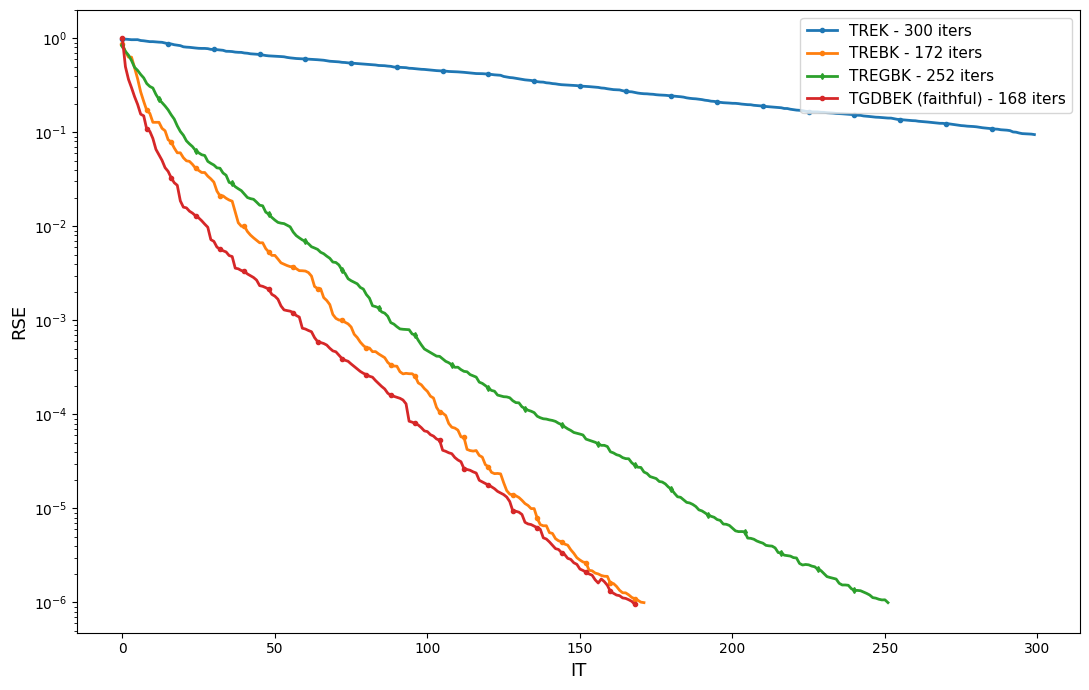

In [30]:
histories = [
  {'name': 'TREK', 'history': hist_trek_sp, 'iterations': k_trek_sp},
  {'name': 'TREBK', 'history': hist_trebk_sp, 'iterations': k_trebk_sp},
  {'name': 'TREGBK', 'history': hist_tregbk_sp, 'iterations': k_tregbk_sp, 'marker': 'd'},
  # {'name': 'TREABK', 'history': hist_treabk_sp, 'iterations': k_treabk_sp},
  {'name': 'TGDBEK (faithful)', 'history': hist_tgdbek_f_sp, 'iterations': k_tgdbek_f_sp},
  # {'name': 'TGDBEK (random)', 'history': hist_tgdbek_rnd_sp, 'iterations': k_tgdbek_rnd_sp,'linewidth': 2.5, 'linestyle': '--', 'marker': 'd'}

]
plot_convergence(histories)

### 3.2. Cities

#### Set the problem

In [32]:
# p doit etre un diviseur de n. p = 5
A_csr = ssp_mat_list[2]

print("Shape of A_csr", A_csr.shape)

p = 2
M_sp = matrix_to_tensor_split_cols(A_csr, p, device=None, dtype=torch.float32)
m, n, _ = M_sp.shape

print(f"Shape of M: {M_sp.shape}")

noise_level=1e-3

X_sp_ls, X_true,  B_sp = make_tensor_system_from_A(M_sp, K=p, noise_level=noise_level, seed=1)

print(f"Shape of X_true:{X_true.shape}, shape of X_ls: {X_sp_ls.shape}, Shape of B:{B_sp.shape}")
# print(f"

tol = 1e-6
alpha =12.0
delta = .7
eta=.5

max_iter = 6000

Shape of A_csr (55, 46)
Shape of M: torch.Size([55, 23, 2])
Shape of X_true:torch.Size([23, 2, 2]), shape of X_ls: torch.Size([23, 2, 2]), Shape of B:torch.Size([55, 2, 2])


#### Partitions utilities

In [33]:
#  1. Partitions for TREBK. It requires both row and col partitions. # In the paper, they used
#  Sequential generations with s= number of partitions, and tau = their size.
row_partitions_trebk_sp = make_partitions(m,  tau=10, sequential=True)
col_partitions_trebk_sp = make_partitions(n, tau=10, sequential=True)

#  2. Partitions for TREGBK. It only requires partitioning the rows in s blocks
row_partitions_tregbk_sp = make_partitions(m, tau=10, sequential=True)

#  3. Partitions for TREABK:  The same block partitions style as 1.
row_partitions_treabk_sp = make_partitions(m, tau=10, sequential=True)
col_partitions_treabk_sp = make_partitions(n, tau=10, sequential=True)

print(f"Row and col  partitions TREBK: {(len(row_partitions_treabk_sp), len(col_partitions_trebk_sp))}")
print(f"Row and col  partitions TREGBK: {(len(row_partitions_tregbk_sp), "_ ")}")
print(f"Row and col  partitions TREABK: {(len(row_partitions_treabk_sp), len(col_partitions_treabk_sp))}")

Row and col  partitions TREBK: (6, 3)
Row and col  partitions TREGBK: (6, '_ ')
Row and col  partitions TREABK: (6, 3)


#### Run  the experiments

In [35]:

(X_trek_sp, k_trek_sp, hist_trek_sp, x_hist_trek_sp), t_trek_sp = trek_algorithm(M_sp, B_sp,  x_ls=X_sp_ls, T=max_iter, tol=tol)


(X_trebk_sp, k_trebk_sp, hist_trebk_sp, x_hist_trebk_sp), t_trebk_sp = trebk_algorithm(M_sp, B_sp,x_ls =X_sp_ls,T=max_iter, tol=tol,\
                                              row_partitions=row_partitions_trebk_sp, col_partitions=col_partitions_trebk_sp)

(X_tregbk_sp, k_tregbk_sp, hist_tregbk_sp, x_hist_tregbk_sp), t_tregbk_sp  = tregbk_algorithm(M_sp, B_sp, x_ls =X_sp_ls,T=max_iter, delta=delta, tol=tol, \
                                              row_partitions=row_partitions_tregbk_sp)

# (X_treabk_sp, k_treabk_sp, hist_treabk_sp, x_hist_treabk_sp), t_treabk_sp = treabk_algorithm(M_sp, B_sp, x_ls =X_sp_ls,T=max_iter, alpha=alpha, tol=tol,\
#                                         row_partitions=row_partitions_treabk_sp, col_partitions=col_partitions_treabk_sp)

(X_tgdbek_f_sp, k_tgdbek_f_sp, hist_tgdbek_f_sp, x_hist_tgdbek_f_sp), t_tgdbek_f_sp = tgdbek_algorithm(M_sp, B_sp, T=max_iter, x_ls=X_sp_ls,eta=eta, tol=tol, rcond=1e-2)

# (X_tgdbek_rnd_sp, k_tgdbek_rnd_sp, hist_tgdbek_rnd_sp, x_hist_tgdbek_rnd_sp), t_tgdbek_sp = tgdbek_algorithm_faithful_rnd_row(M_sp, B_sp, T=max_iter, x_ls=X_sp_ls,eta=eta, tol=tol)


In [36]:

results = [
    {'name': 'TREK', 'time': t_trek_sp, 'final_residual': hist_trek_sp[-1], 'iterations': k_trek_sp},
    {'name': 'TREBK', 'time': t_trebk_sp, 'final_residual': hist_trebk_sp[-1], 'iterations': k_trebk_sp},
    {'name': 'TREGBK', 'time': t_tregbk_sp, 'final_residual': hist_tregbk_sp[-1], 'iterations': k_tregbk_sp},
    # {'name': 'TREABK', 'time': t_treabk_sp, 'final_residual': hist_treabk_sp[-1], 'iterations': k_treabk_sp},
    # {'name': 'TGDBEK (Proposed)', 'time': t_tgdbek_sp, 'final_residual': hist_tgdbek_sp[-1], 'iterations': k_tgdbek_sp},
    {'name': 'TGDBEK _f (good)', 'time': t_tgdbek_f_sp, 'final_residual': hist_tgdbek_f_sp[-1], 'iterations': k_tgdbek_f_sp},
    # {'name': 'TGDBEK _f (random)', 'time': t_tgdbek_sp, 'final_residual': hist_tgdbek_rnd_sp[-1], 'iterations': k_tgdbek_rnd_sp}
  ]

display_results(results)

BENCHMARK RESULTS - TENSOR KACZMARZ METHODS (Using T-Product)
          Method  Time (s)  Final Relative Residual  Iterations
            TREK  8.051987             3.804321e-03        6000
           TREBK  3.701447             9.634076e-07        2545
          TREGBK 11.180961             9.828715e-07        5075
TGDBEK _f (good)  2.748848             9.915972e-07        1397


,Method,Time (s),Final Relative Residual,Iterations
0,TREK,8.051987,3.804321e-03,6000
1,TREBK,3.701447,9.634076e-07,2545
2,TREGBK,11.180961,9.828715e-07,5075
3,TGDBEK _f (good),2.748848,9.915972e-07,1397


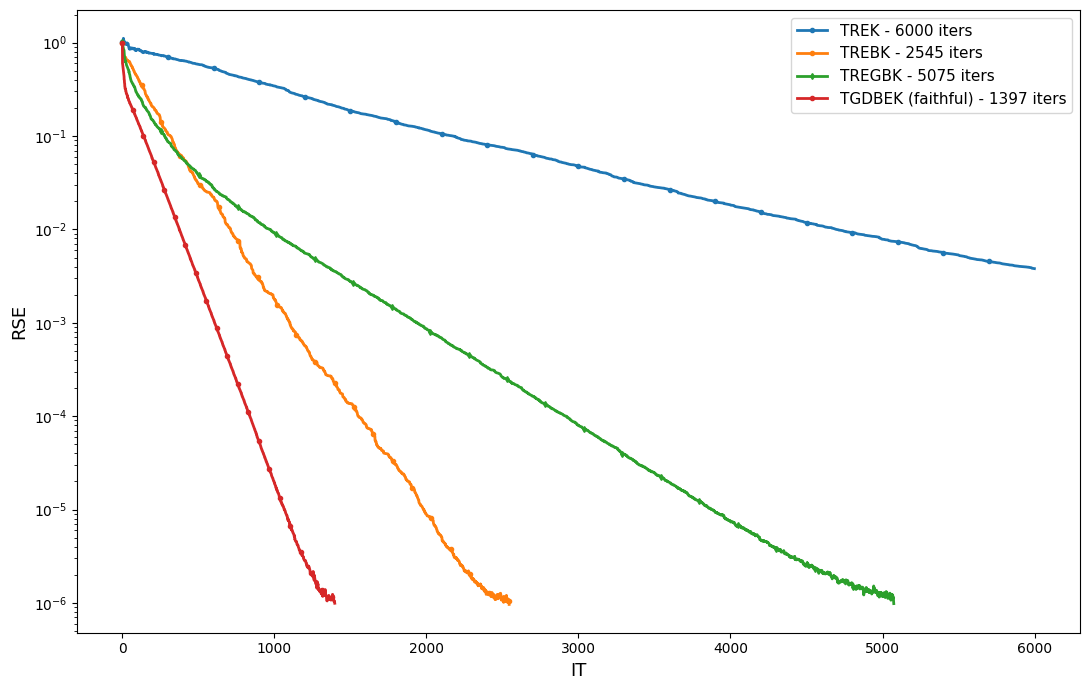

In [37]:
histories = [
  {'name': 'TREK', 'history': hist_trek_sp, 'iterations': k_trek_sp},
  {'name': 'TREBK', 'history': hist_trebk_sp, 'iterations': k_trebk_sp},
  {'name': 'TREGBK', 'history': hist_tregbk_sp, 'iterations': k_tregbk_sp, 'marker': 'd'},
  # {'name': 'TREABK', 'history': hist_treabk_sp, 'iterations': k_treabk_sp},
  {'name': 'TGDBEK (faithful)', 'history': hist_tgdbek_f_sp, 'iterations': k_tgdbek_f_sp},
  # {'name': 'TGDBEK (random)', 'history': hist_tgdbek_rnd_sp, 'iterations': k_tgdbek_rnd_sp,'linewidth': 2.5, 'linestyle': '--', 'marker': 'd'}
]
plot_convergence(histories)

### 3.3. WorldCities
<!-- ['nos5', 'ash85', 'Cities', 'WorldCities', 'gre_216a'] -->

#### Setting up the problem.

In [38]:
# p doit etre un diviseur de n. p = 5
A_csr = ssp_mat_list[3]

print("Shape of A_csr", A_csr.shape)

p = 10
M_sp = matrix_to_tensor_split_cols(A_csr, p, device=None, dtype=torch.float32)
m, n, _ = M_sp.shape

print(f"Shape of M: {M_sp.shape}")

noise_level=1e-1

X_sp_ls, X_true,  B_sp = make_tensor_system_from_A(M_sp, K=p, noise_level=noise_level, seed=1)

print(f"Shape of X_true:{X_true.shape}, shape of X_ls: {X_sp_ls.shape}, Shape of B:{B_sp.shape}")
# print(f"

tol = 1e-6
alpha =12.0
delta = .7
eta=.7

max_iter = 6000

Shape of A_csr (315, 100)
Shape of M: torch.Size([315, 10, 10])
Shape of X_true:torch.Size([10, 10, 10]), shape of X_ls: torch.Size([10, 10, 10]), Shape of B:torch.Size([315, 10, 10])


#### Partitions utilities

In [41]:

# Partitions
#  1. Partitions for TREBK. It requires both row and col partitions. # In the paper, they used
#  Sequential generations with s= number of partitions, and tau = their size.
row_partitions_trebk_sp = make_partitions(m,  tau=10, sequential=True)
col_partitions_trebk_sp = make_partitions(n, tau=10, sequential=True)

#  2. Partitions for TREGBK. It only requires partitioning the rows in s blocks
row_partitions_tregbk_sp = make_partitions(m, tau=10, sequential=True)

#  3. Partitions for TREABK:  The same block partitions style as 1.
row_partitions_treabk_sp = make_partitions(m, tau=10, sequential=True)
col_partitions_treabk_sp = make_partitions(n, tau=10, sequential=True)

print(f"Row and col  partitions TREBK: {(len(row_partitions_treabk_sp), len(col_partitions_trebk_sp))}")
print(f"Row and col  partitions TREGBK: {(len(row_partitions_tregbk_sp), "_ ")}")
print(f"Row and col  partitions TREABK: {(len(row_partitions_treabk_sp), len(col_partitions_treabk_sp))}")

Row and col  partitions TREBK: (32, 1)
Row and col  partitions TREGBK: (32, '_ ')
Row and col  partitions TREABK: (32, 1)


#### Run  the experiments

In [42]:
(X_trek_sp, k_trek_sp, hist_trek_sp, x_hist_trek_sp), t_trek_sp = trek_algorithm(M_sp, B_sp,  x_ls=X_sp_ls, T=max_iter, tol=tol)


(X_trebk_sp, k_trebk_sp, hist_trebk_sp, x_hist_trebk_sp), t_trebk_sp = trebk_algorithm(M_sp, B_sp,x_ls =X_sp_ls,T=max_iter, tol=tol,\
                                              row_partitions=row_partitions_trebk_sp, col_partitions=col_partitions_trebk_sp)

(X_tregbk_sp, k_tregbk_sp, hist_tregbk_sp, x_hist_tregbk_sp), t_tregbk_sp  = tregbk_algorithm(M_sp, B_sp, x_ls =X_sp_ls,T=max_iter, delta=delta, tol=tol, \
                                              row_partitions=row_partitions_tregbk_sp)

# (X_treabk_sp, k_treabk_sp, hist_treabk_sp, x_hist_treabk_sp), t_treabk_sp = treabk_algorithm(M_sp, B_sp, x_ls =X_sp_ls,T=max_iter, alpha=alpha, tol=tol,\
#                                         row_partitions=row_partitions_treabk_sp, col_partitions=col_partitions_treabk_sp)

(X_tgdbek_f_sp, k_tgdbek_f_sp, hist_tgdbek_f_sp, x_hist_tgdbek_f_sp), t_tgdbek_f_sp = tgdbek_algorithm(M_sp, B_sp, T=max_iter, x_ls=X_sp_ls,eta=eta, tol=tol, rcond=1e-2)



In [43]:
results = [
    {'name': 'TREK', 'time': t_trek_sp, 'final_residual': hist_trek_sp[-1], 'iterations': k_trek_sp},
    {'name': 'TREBK', 'time': t_trebk_sp, 'final_residual': hist_trebk_sp[-1], 'iterations': k_trebk_sp},
    {'name': 'TREGBK', 'time': t_tregbk_sp, 'final_residual': hist_tregbk_sp[-1], 'iterations': k_tregbk_sp},
    # {'name': 'TREABK', 'time': t_treabk_sp, 'final_residual': hist_treabk_sp[-1], 'iterations': k_treabk_sp},
    # {'name': 'TGDBEK (Proposed)', 'time': t_tgdbek_sp, 'final_residual': hist_tgdbek_sp[-1], 'iterations': k_tgdbek_sp},
    {'name': 'TGDBEK _f (good)', 'time': t_tgdbek_f_sp, 'final_residual': hist_tgdbek_f_sp[-1], 'iterations': k_tgdbek_f_sp},
    # {'name': 'TGDBEK _f (random)', 'time': t_tgdbek_sp, 'final_residual': hist_tgdbek_rnd_sp[-1], 'iterations': k_tgdbek_rnd_sp}
  ]

display_results(results)

BENCHMARK RESULTS - TENSOR KACZMARZ METHODS (Using T-Product)
          Method  Time (s)  Final Relative Residual  Iterations
            TREK  9.058722                      NaN        6000
           TREBK  0.032008             9.784992e-07           6
          TREGBK  2.577174             9.688072e-07         522
TGDBEK _f (good)  0.007441             5.419030e-07           1


,Method,Time (s),Final Relative Residual,Iterations
0,TREK,9.058722,NaN,6000
1,TREBK,0.032008,9.784992e-07,6
2,TREGBK,2.577174,9.688072e-07,522
3,TGDBEK _f (good),0.007441,5.419030e-07,1


In [45]:
# histories = [
#   {'name': 'TREK', 'history': hist_trek_sp, 'iterations': k_trek_sp},
#   {'name': 'TREBK', 'history': hist_trebk_sp, 'iterations': k_trebk_sp},
#   {'name': 'TREGBK', 'history': hist_tregbk_sp, 'iterations': k_tregbk_sp, 'marker': 'd'},
#   # {'name': 'TREABK', 'history': hist_treabk_sp, 'iterations': k_treabk_sp},
#   {'name': 'TGDBEK (faithful)', 'history': hist_tgdbek_f_sp, 'iterations': k_tgdbek_f_sp},
#   # {'name': 'TGDBEK (random)', 'history': hist_tgdbek_rnd_sp, 'iterations': k_tgdbek_rnd_sp,'linewidth': 2.5, 'linestyle': '--', 'marker': 'd'}
# ]

# plot_convergence(histories)

### 3.4. gre_216a

#### Setting up the problem

In [46]:
# p doit etre un diviseur de n. p = 5
A_csr = ssp_mat_list[3]

print("Shape of A_csr", A_csr.shape)

p = 10
M_sp = matrix_to_tensor_split_cols(A_csr, p, device=None, dtype=torch.float32)
m, n, _ = M_sp.shape

print(f"Shape of M: {M_sp.shape}")

noise_level=1e-3

X_sp_ls, X_true,  B_sp = make_tensor_system_from_A(M_sp, K=p, noise_level=noise_level, seed=1)

print(f"Shape of X_true:{X_true.shape}, shape of X_ls: {X_sp_ls.shape}, Shape of B:{B_sp.shape}")
# print(f"

tol = 1e-6
alpha =12.0
delta = .7
eta=.5

max_iter = 6000

Shape of A_csr (315, 100)
Shape of M: torch.Size([315, 10, 10])
Shape of X_true:torch.Size([10, 10, 10]), shape of X_ls: torch.Size([10, 10, 10]), Shape of B:torch.Size([315, 10, 10])


#### Partitions utilities

In [47]:

# Partitions
#  1. Partitions for TREBK. It requires both row and col partitions. # In the paper, they used
#  Sequential generations with s= number of partitions, and tau = their size.
row_partitions_trebk_sp = make_partitions(m,  tau=10, sequential=True)
col_partitions_trebk_sp = make_partitions(n, tau=10, sequential=True)

#  2. Partitions for TREGBK. It only requires partitioning the rows in s blocks
row_partitions_tregbk_sp = make_partitions(m, tau=10, sequential=True)

#  3. Partitions for TREABK:  The same block partitions style as 1.
row_partitions_treabk_sp = make_partitions(m, tau=10, sequential=True)
col_partitions_treabk_sp = make_partitions(n, tau=10, sequential=True)

print(f"Row and col  partitions TREBK: {(len(row_partitions_treabk_sp), len(col_partitions_trebk_sp))}")
print(f"Row and col  partitions TREGBK: {(len(row_partitions_tregbk_sp), "_ ")}")
print(f"Row and col  partitions TREABK: {(len(row_partitions_treabk_sp), len(col_partitions_treabk_sp))}")

Row and col  partitions TREBK: (32, 1)
Row and col  partitions TREGBK: (32, '_ ')
Row and col  partitions TREABK: (32, 1)


#### Run  the experiments

In [48]:

(X_trek_sp, k_trek_sp, hist_trek_sp, x_hist_trek_sp), t_trek_sp = trek_algorithm(M_sp, B_sp,  x_ls=X_sp_ls, T=max_iter, tol=tol)


(X_trebk_sp, k_trebk_sp, hist_trebk_sp, x_hist_trebk_sp), t_trebk_sp = trebk_algorithm(M_sp, B_sp,x_ls =X_sp_ls,T=max_iter, tol=tol,\
                                              row_partitions=row_partitions_trebk_sp, col_partitions=col_partitions_trebk_sp)

(X_tregbk_sp, k_tregbk_sp, hist_tregbk_sp, x_hist_tregbk_sp), t_tregbk_sp  = tregbk_algorithm(M_sp, B_sp, x_ls =X_sp_ls,T=max_iter, delta=delta, tol=tol, \
                                              row_partitions=row_partitions_tregbk_sp)

# (X_treabk_sp, k_treabk_sp, hist_treabk_sp, x_hist_treabk_sp), t_treabk_sp = treabk_algorithm(M_sp, B_sp, x_ls =X_sp_ls,T=max_iter, alpha=alpha, tol=tol,\
#                                         row_partitions=row_partitions_treabk_sp, col_partitions=col_partitions_treabk_sp)

(X_tgdbek_f_sp, k_tgdbek_f_sp, hist_tgdbek_f_sp, x_hist_tgdbek_f_sp), t_tgdbek_f_sp = tgdbek_algorithm(M_sp, B_sp, T=max_iter, x_ls=X_sp_ls,eta=eta, tol=tol, rcond=1e-2)



In [49]:

results = [
    {'name': 'TREK', 'time': t_trek_sp, 'final_residual': hist_trek_sp[-1], 'iterations': k_trek_sp},
    {'name': 'TREBK', 'time': t_trebk_sp, 'final_residual': hist_trebk_sp[-1], 'iterations': k_trebk_sp},
    {'name': 'TREGBK', 'time': t_tregbk_sp, 'final_residual': hist_tregbk_sp[-1], 'iterations': k_tregbk_sp},
    # {'name': 'TREABK', 'time': t_treabk_sp, 'final_residual': hist_treabk_sp[-1], 'iterations': k_treabk_sp},
    # {'name': 'TGDBEK (Proposed)', 'time': t_tgdbek_sp, 'final_residual': hist_tgdbek_sp[-1], 'iterations': k_tgdbek_sp},
    {'name': 'TGDBEK _f (good)', 'time': t_tgdbek_f_sp, 'final_residual': hist_tgdbek_f_sp[-1], 'iterations': k_tgdbek_f_sp},
    # {'name': 'TGDBEK _f (random)', 'time': t_tgdbek_sp, 'final_residual': hist_tgdbek_rnd_sp[-1], 'iterations': k_tgdbek_rnd_sp}
  ]
display_results(results)

BENCHMARK RESULTS - TENSOR KACZMARZ METHODS (Using T-Product)
          Method  Time (s)  Final Relative Residual  Iterations
            TREK 10.306071                      NaN        6000
           TREBK  0.033028             9.704011e-07           6
          TREGBK  2.626072             9.779991e-07         521
TGDBEK _f (good)  0.008178             5.001754e-07           1


,Method,Time (s),Final Relative Residual,Iterations
0,TREK,10.306071,NaN,6000
1,TREBK,0.033028,9.704011e-07,6
2,TREGBK,2.626072,9.779991e-07,521
3,TGDBEK _f (good),0.008178,5.001754e-07,1


In [51]:
# histories = [
#   {'name': 'TREK', 'history': hist_trek_sp, 'iterations': k_trek_sp},
#   {'name': 'TREBK', 'history': hist_trebk_sp, 'iterations': k_trebk_sp},
#   {'name': 'TREGBK', 'history': hist_tregbk_sp, 'iterations': k_tregbk_sp, 'marker': 'd'},
#   # {'name': 'TREABK', 'history': hist_treabk_sp, 'iterations': k_treabk_sp},
#   {'name': 'TGDBEK (faithful)', 'history': hist_tgdbek_f_sp, 'iterations': k_tgdbek_f_sp},
#   # {'name': 'TGDBEK (random)', 'history': hist_tgdbek_rnd_sp, 'iterations': k_tgdbek_rnd_sp,'linewidth': 2.5, 'linestyle': '--', 'marker': 'd'}

# ]

# plot_convergence(histories)

# Application to color image deblurring